In [1]:
from universe import *
from halo_fit import *
from weight import *
from pn_2d import *
from cmb import *
from flat_map import *
from scipy.integrate import simpson as simps
from scipy.special import jv,jvp
from math import factorial
from hankel import HankelTransform as hnkl
from patchy_penalty import *

# cmb lensing power spectrum
u = UnivPlanck15()
halofit = Halofit(u, save=False)
w_cmblens = WeightLensSingle(u, z_source=1100., name="cmblens")
p2d_cmblens = P2dAuto(u, halofit, w_cmblens, save=False)
# number of pixels for the flat map
nX = 1024 #1200
nY = 1024 #1200
# map dimensions in degrees
sizeX = 2.
sizeY = 2.
# basic map object
baseMap = FlatMap(nX=nX, nY=nY, sizeX=sizeX*np.pi/180., sizeY=sizeY*np.pi/180.)
# multipoles to include in the lensing reconstruction
lMin = 30.; lMax = 7.e3
# Adjust the lMin and lMax to the assumptions of the analysis
# CMB S3 specs
cmb = CMB(beam=1.4, noise=12., lMin=lMin, lMaxT=lMax, lMaxP=lMax, fg=True, atm=False)
# Total power spectrum, for the lens reconstruction
forCtotal = lambda l: cmb.ftotalTT(l)
# reinterpolate: gain factor 10 in speed
L = np.logspace(np.log10(lMin/2.), np.log10(2.*lMax), 1001, 10.)
F = np.array(list(map(forCtotal, L)))
cmb.fCtotal = interp1d(L, F, kind='linear', bounds_error=False, fill_value=0.)

import matplotlib
from matplotlib.pyplot import rc
import matplotlib.font_manager

rc('font',**{'size':'22','family':'serif','serif':['CMU serif']})
rc('mathtext', **{'fontset':'cm'})
rc('text', usetex=True)
rc('legend',**{'fontsize':'18'})

matplotlib.rcParams['axes.linewidth'] = 3
matplotlib.rcParams['axes.labelsize'] = 30
matplotlib.rcParams['xtick.labelsize'] = 25 
matplotlib.rcParams['ytick.labelsize'] = 25
matplotlib.rcParams['legend.fontsize'] = 25
matplotlib.rcParams['xtick.major.size'] = 10
matplotlib.rcParams['ytick.major.size'] = 10
matplotlib.rcParams['xtick.minor.size'] = 5
matplotlib.rcParams['ytick.minor.size'] = 5
matplotlib.rcParams['xtick.major.width'] = 3
matplotlib.rcParams['ytick.major.width'] = 3
matplotlib.rcParams['xtick.minor.width'] = 1.5
matplotlib.rcParams['ytick.minor.width'] = 1.5
matplotlib.rcParams['axes.titlesize'] = 30
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

/home/noah/Berkeley/FlatSkyQE/basic_functions.py:98: RuntimeWarning: divide by zero encountered in divide
  try: return x/y
/home/noah/Berkeley/FlatSkyQE/cmb.py:127: RuntimeWarning: invalid value encountered in multiply
  data[:,1] *= self.fdl_to_cl(data[:,0]) # convert Dl to Cl
/home/noah/Berkeley/FlatSkyQE/cmb.py:135: RuntimeWarning: invalid value encountered in multiply
  data[:,1] *= self.fdl_to_cl(data[:,0]) # convert Dl to Cl
/home/noah/Berkeley/FlatSkyQE/cmb.py:149: RuntimeWarning: invalid value encountered in multiply
  data[:,1] *= self.fdl_to_cl(data[:,0]) # convert Dl to Cl


# Lensed temperature power spectrum.

\begin{equation}
\begin{aligned}
    C^{TT}_\ell
    &=
    \int R\,dR\,\,
    J_0(\ell R)
    \int q\,dq\,\,
    e^{-q^2\mathcal{B}(R)}
    C^0_q
    \int \frac{d\theta}{2\pi}
    e^{-q^2\mathcal{A}(R)\cos^2(\theta)} e^{iqR\cos(\theta)}
    \\
    &=
    \int R\,dR\,\,
    J_0(\ell R)
    \sum_{n=0}^\infty
    \frac{\big[\mathcal{A}(R)\big]^n}{n!R^{2n}}
    \int dq\,\,
    e^{-q^2\mathcal{B}(R)}
    C^0_q q^{2n+1}
    \frac{d^{2n} J_0(qR)}{dq^{2n}}
    \\
    &=
    \int R\,dR\,\,
    J_0(\ell R)
    \sum_{n=0}^\infty
    \frac{\big[\mathcal{A}(R)\big]^n}{n!R^{2n}}
    \int dq\,\,J_0(qR)
    \frac{d^{2n}}{dq^{2n}}[
    e^{-q^2\mathcal{B}(R)}
    C^0_q q^{2n+1}]
\end{aligned}
\end{equation}
where I defined
\begin{equation}
\begin{aligned}
    \mathcal{A}(R) 
    &\equiv 
    \int \frac{\ell^3 d\ell}{2\pi} J_2(\ell R)
    C^{\phi\phi}_\ell
    \\
    \mathcal{B}(R) 
    &\equiv 
    \int \frac{\ell^3 d\ell}{2\pi} 
    \bigg[
    \frac{1}{2}-\frac{J_1(\ell R)}{\ell R}
    \bigg]
    C^{\phi\phi}_\ell
\end{aligned}
\end{equation}

In [2]:
# Compute A(R) and B(R)
Cpp = lambda l: 4*p2d_cmblens.fPinterp(l)*4/l**4
RA  = np.logspace(np.log10(0.1/60*np.pi/180),1,100)
A   = hnkl(nu=2,h=1e-5).transform(lambda l: l**2*Cpp(l)/(2*np.pi),k=RA,ret_err=False)
RB  = np.array([0.1/60*np.pi/180,1/60*np.pi/180] + np.logspace(np.log10(2/60*np.pi/180),1,25).tolist())
B   = hnkl(nu=1,h=4e-7).transform(lambda l: l*Cpp(l)/(2*np.pi),k=RB,ret_err=False)/RB
B   = B[0] - B
R   = np.logspace(np.log10(max(RA[0],RB[0])), np.log10(min(RA[-1],RB[-1])),500)
A,B = np.interp(R,RA,A),np.interp(R,RB,B)

Text(0.5, 0, '$R$ [arcmin]')

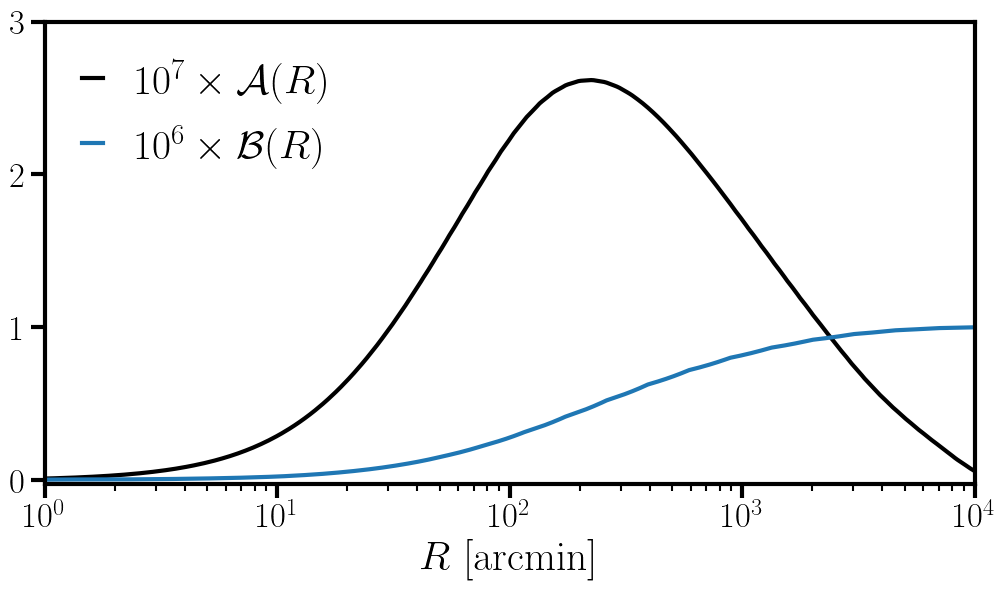

In [3]:
# and plot them
plt.figure(figsize=(12,6))
plt.plot(R*180/np.pi*60,1e7*A,lw=3,label=r'$10^7\times\mathcal{A}(R)$',c='k')
plt.plot(R*180/np.pi*60,1e6*B,lw=3,label=r'$10^6\times\mathcal{B}(R)$',c='C0')
plt.xscale('log')
plt.yscale('linear')
plt.xlim(1,1e4)
plt.ylim(-0.02,3)
plt.legend(loc='upper left',frameon=False,fontsize=30,handlelength=0.5)
plt.xlabel(r'$R$ [arcmin]')

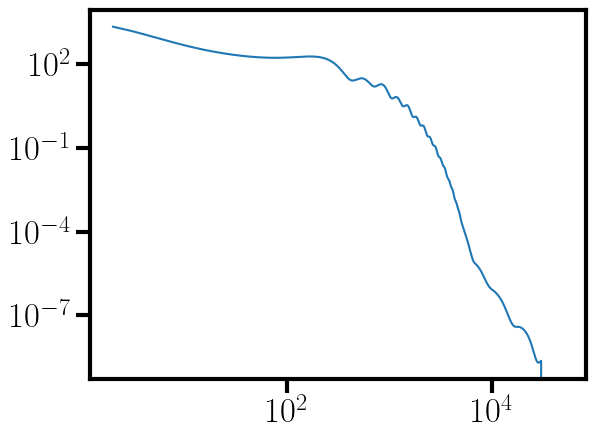

In [20]:
q = np.arange(50000)[2:]
plt.loglog(q,q*cmb.funlensedTT(q))

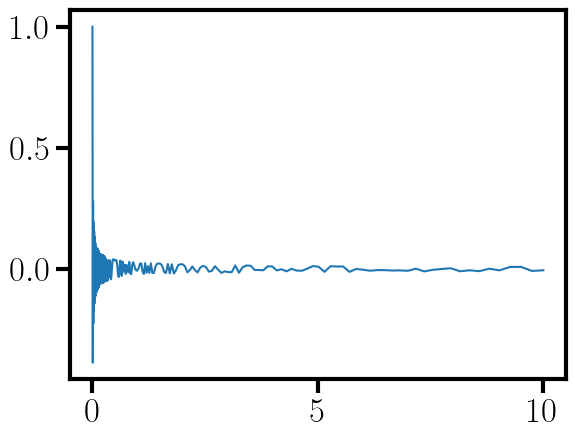

In [22]:
theta     = np.linspace(0,2*np.pi,100000)
integrand = lambda theta,q: np.exp(-q**2*(B+A*np.cos(theta)**2))*np.cos(R*q*np.cos(theta))
integral  = lambda q: np.trapz([integrand(t,q)/2/np.pi for t in theta],x=theta,axis=0)


plt.plot(R,integral(500))

In [32]:
def psum(nmax=2,qmax=2e4,nq=10000):
    q     = np.logspace(np.log10(2.),np.log10(qmax),nq)
    QQ,RR = np.meshgrid(q,R,indexing='ij')
    _ ,AA = np.meshgrid(q,A,indexing='ij')
    _ ,BB = np.meshgrid(q,B,indexing='ij')
    res   = np.zeros_like(QQ)
    for n in range(1,nmax+1): res += (QQ**2*AA)**n*jvp(0,QQ*RR,2*n)/factorial(n)
    res  *= QQ*cmb.funlensedTT(QQ)*np.exp(-QQ**2*BB)
    return simps(res,x=q,axis=0)
    
I   = psum(nmax=8,qmax=2e4,nq=int(1e4))
L   = np.logspace(np.log10(100),np.log10(10000),500)
CTT = cmb.funlensedTT(L)
CTT+= hnkl(nu=0,h=1e-1).transform(lambda r: np.interp(r,R,I),k=L,ret_err=False)

(-1.0, 2.0)

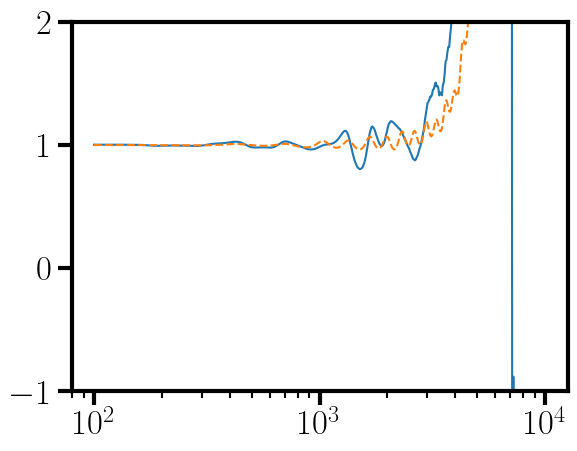

In [38]:
plt.semilogx(L,CTT/cmb.funlensedTT(L))
plt.semilogx(L,cmb.flensedTT(L)/cmb.funlensedTT(L),ls='--')
plt.ylim(-1,2)

# Contour integral

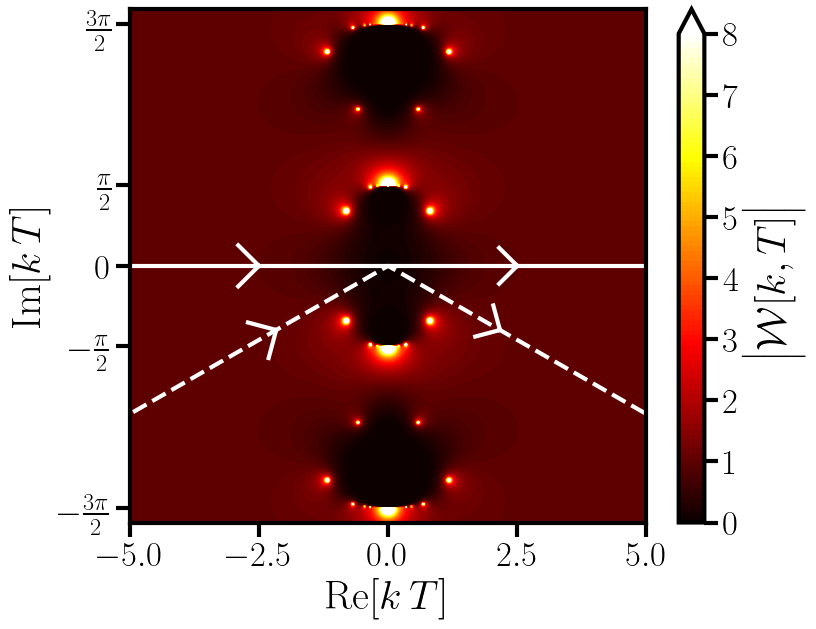

In [17]:
Lambda = 0.5
k      = 1
zr_min, zr_max = -5,5
zi_min, zi_max = -5,5
fig,ax = plt.subplots(1,1,figsize=(10/1.2,8/1.2))
ticks  = [0,1,2,3,4,5,6,7,8]
zr = np.linspace(zr_min,zr_max,500)
zi = np.linspace(zi_min,zi_max,500)
ZR,ZI = np.meshgrid(zr,zi)
Z = ZR+ZI*1.j
F = np.tanh(k*Z)*(1 + np.tanh(k*Z*np.tanh(k*Z) - k*Lambda))/2.
levels = np.linspace(ticks[0],ticks[-1],100,endpoint=True)
contour = ax.contourf(ZR,ZI,np.abs(F),cmap='hot',levels=levels,extend='max')
plt.colorbar(contour, ticks=ticks,label=r'$\big|\mathcal{W}[k,T]\big|$')
def draw_leftside_arrow(ls='-',c='w',theta=0.,lw=3,delt=0.4):
    R = np.array([[np.cos(theta),np.sin(theta)],[-1.*np.sin(theta),np.cos(theta)]])
    L = np.dot(R,np.array([2*zr_min,0.]))
    ax.plot([L[0],0],[L[1],0],c=c,ls=ls,lw=lw)
    p1 = np.dot(R,np.array([zr_min/2,0.]))
    p2 = np.dot(R,np.array([zr_min/2-delt,delt]))
    p3 = np.dot(R,np.array([zr_min/2-delt,-1.*delt]))
    ax.plot([p1[0],p2[0]],[p1[1],p2[1]],c=c,ls='-',lw=lw)
    ax.plot([p1[0],p3[0]],[p1[1],p3[1]],c=c,ls='-',lw=lw)
draw_leftside_arrow()
draw_leftside_arrow(theta=-np.pi/6,ls='--')
def draw_rightside_arrow(ls='-',c='w',theta=0.,lw=3,delt=0.35):
    R = np.array([[np.cos(theta),np.sin(theta)],[-1.*np.sin(theta),np.cos(theta)]])
    L = np.dot(R,np.array([2*zr_max,0.]))
    ax.plot([L[0],0],[L[1],0],c=c,ls=ls,lw=lw)
    p1 = np.dot(R,np.array([zr_max/2,0.]))
    p2 = np.dot(R,np.array([zr_max/2-delt,delt]))
    p3 = np.dot(R,np.array([zr_max/2-delt,-1.*delt]))
    ax.plot([p1[0],p2[0]],[p1[1],p2[1]],c=c,ls='-',lw=lw)
    ax.plot([p1[0],p3[0]],[p1[1],p3[1]],c=c,ls='-',lw=lw)
draw_rightside_arrow()
draw_rightside_arrow(theta=np.pi/6,ls='--')
#ax.text(2.5,-0.8,r'$\boldsymbol{\theta = \epsilon/\omega}$',color='w')
ax.set_xlabel(r'$\text{Re}[k\,T]$')
ax.set_ylabel(r'$\text{Im}[k\,T]$')
ax.set_xlim(zr_min, zr_max)
ax.set_ylim(zi_min, zi_max)
ax.set_yticks([-3*np.pi/2+np.pi*n for n in range(4)]+[0],[r'$-\frac{3\pi}{2}$',r'$-\frac{\pi}{2}$',r'$\frac{\pi}{2}$',r'$\frac{3\pi}{2}$',r'$0$'])
plt.savefig('../../Downloads/contour_plot.pdf',bbox_inches='tight')

# Linear responses

In [2]:
def get_beam(l,theta=1.6): return np.exp(-0.5*((theta*np.pi/180/60)*l)**2/(8*np.log(2)))

def get_pixwin(l,theta=0.25/60*np.pi/180): return np.sin((l+1e-4)*theta/2)/((l+1e-4)*theta/2)

def Wlow_(l):
    # the low-pass filter has been beam deconvolved
    if l<2000: return 1.
    if l>2150: return 0.
    return np.cos((l-2000.)*np.pi/300.)

def Whi_(l,theta=1.6,lc=12000):
    if l>lc: return 0.
    if l>2500: return get_beam(l)
    if l<2350: return 0.
    return np.sin((l-2350.)*np.pi/300.)*get_beam(l,theta=theta)

Wlow = lambda l: np.vectorize(Wlow_)(l)

def Whi(l,theta,lc):
    return np.array([Whi_(q,theta,lc) for q in l])

#Whi  = lambda l,theta,lc: np.vectorize(lambda q: Whi_(q,theta,lc))(l)

def I(L,l,ntheta=300,theta=1.6,lc=12000):
    Theta = np.linspace(0,2*np.pi,ntheta)
    Wlow_l = Wlow(l)
    Whi_l  = Whi(l*np.ones_like(Theta),theta,lc)
    Wlow_Ll= Wlow((L**2+l**2-2*L*l*np.cos(Theta))**0.5)
    Whi_Ll = Whi((L**2+l**2-2*L*l*np.cos(Theta))**0.5,theta,lc)
    integrand = Wlow_l*Whi_Ll + Wlow_Ll*Whi_l
    integrand*= 2*cmb.flensedTT(l)*L*l**2*np.cos(Theta)/(2*np.pi)**2/L**2
    return simps(integrand,Theta)

def J(L,l,ntheta=300,theta=1.6,lc=12000):
    Theta = np.linspace(0,2*np.pi,ntheta)
    Wlow_l = Wlow(l)
    Whi_l  = Whi(l*np.ones_like(Theta),theta,lc)
    Wlow_Ll= Wlow((L**2+l**2-2*L*l*np.cos(Theta))**0.5)
    Whi_Ll = Whi((L**2+l**2-2*L*l*np.cos(Theta))**0.5,theta,lc)
    integrand = Wlow_l*Whi_Ll + Wlow_Ll*Whi_l
    integrand*= cmb.flensedTT(l)*l/(2*np.pi)**2
    return np.trapz(integrand,Theta)

def Fphi(L,lmax=14000,nl=1000,ntheta=100,theta=1.6,lc=12000):
    l = np.linspace(1,lmax,nl)
    integrand = np.array([I(L,ll,ntheta=ntheta,theta=theta,lc=lc) for ll in l])
    return simps(integrand,l)

def Ftau(L,lmax=14000,nl=1000,ntheta=100,theta=1.6,lc=12000):
    l = np.linspace(1,lmax,nl)
    integrand = np.array([-1.*J(L,ll,ntheta=ntheta,theta=theta,lc=lc) for ll in l])
    return np.trapz(integrand,l)

In [3]:
ll = np.linspace(1,3000,500000)
tlsq = simps(ll*Wlow(ll)**2*cmb.flensedTT(ll)/(2*np.pi),ll)
print('<T_l^2> =',np.round(tlsq**0.5,2))

def load_filters(theta,lc):
    try:
        LL,FF = np.loadtxt(f'kappa_bias_filter_thetab-{theta}_lc-{lc}.txt').T
        ll,ff = np.loadtxt(f'tau_bias_filter_thetab-{theta}_lc-{lc}.txt').T
    except:
        L = np.linspace(1,15000+1,500)
        F = [-1*Fphi(LL,theta=theta,lc=lc)/tlsq for LL in L]
        LL = np.arange(1,np.max(L))
        FF = np.interp(LL,L,F)
        LL = np.array([0]+LL.tolist())
        FF = np.array([0]+FF.tolist())
        np.savetxt(f'kappa_bias_filter_thetab-{theta}_lc-{lc}.txt',np.array([LL,FF]).T,header="L, kappa filter")
        ll = np.linspace(1,np.max(L),500)
        ff = [-1*Ftau(LL,theta=theta,lc=lc)/tlsq for LL in ll]
        np.savetxt(f'tau_bias_filter_thetab-{theta}_lc-{lc}.txt',np.array([ll,ff]).T,header="L, tau filter")
    return LL,FF,ll,ff

<T_l^2> = 112.87


In [ ]:
load_filters(1.6,12000)

In [ ]:
load_filters(1.6,10000)

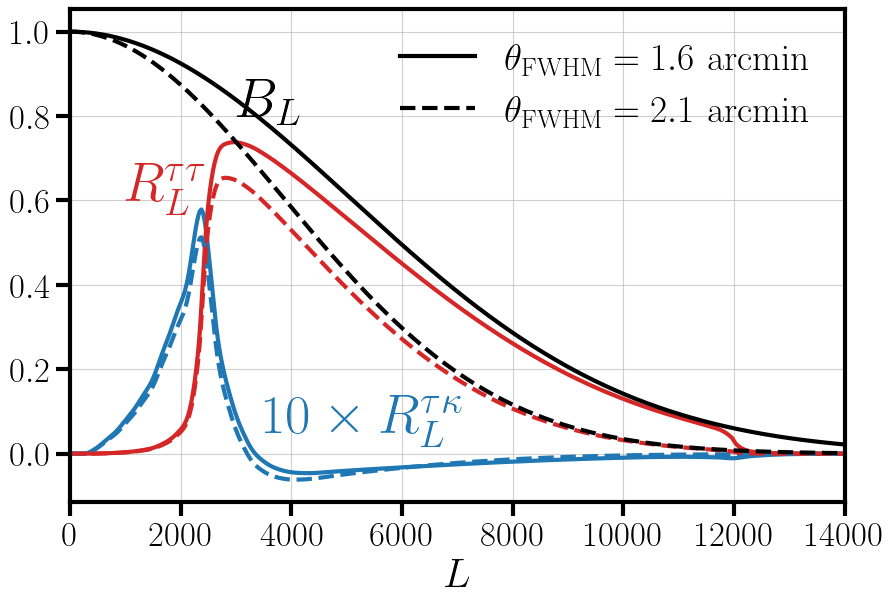

In [11]:
plt.figure(figsize=(10,6.4))
Lk,Fk,Lt,Ft = load_filters(1.6,12000)
plt.plot(Lk,1e1*Fk,c='C0',lw=3)
plt.plot(Lt,Ft,c='C3',lw=3)
plt.plot(Lk,get_beam(Lk,theta=1.6),c='k',lw=3)
plt.xlabel(r'$L$')
plt.xlim(0,14000)
plt.yscale('linear')
plt.grid(alpha=0.6,which='major')
plt.grid(alpha=0.1,which='minor')
plt.text(3500,0.05,r'$10\times R^{\tau\kappa}_L$',color='C0',fontsize=40)
plt.text(1000,0.6,r'$R^{\tau\tau}_L$',color='C3',fontsize=40)
plt.text(3000,0.8,r'$B_L$',fontsize=40)
plt.savefig('../../Downloads/phi_filter.pdf',bbox_inches='tight')

In [6]:
l,ckg0 = np.loadtxt('../../Downloads/lrg_extended_ckg_power_law.txt').T
ckg1   = ckg0/(1+(l/5000))**2

def get_lensing_bias(LL,FF,l=l,ckg=ckg0):
    ckg = np.interp(LL,l,ckg)
    Br  = lambda r: simps(jv(0,r*LL)*LL*FF*ckg/(2*np.pi),LL)
    r = np.linspace(0.01,11,200)*np.pi/60/180 # radians
    B = [Br(rr) for rr in r]
    return r,B

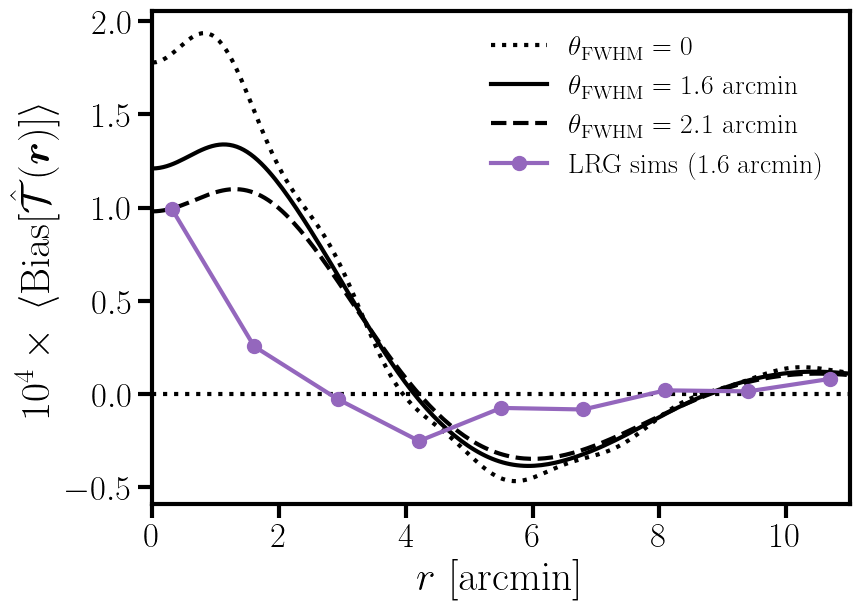

In [7]:
plt.figure(figsize=(9,6.4))

Lk,Fk,Lt,Ft = load_filters(1.6,12000)
r,B  = get_lensing_bias(Lk,Fk)
plt.plot(r/(np.pi/60/180),1e4*np.array(B),c='k',lw=3)

Lk,Fk,Lt,Ft = load_filters(1.6,10000)
r,B  = get_lensing_bias(Lk,Fk)
plt.plot(r/(np.pi/60/180),1e4*np.array(B),c='k',lw=3)

plt.legend(loc='upper right',frameon=False,fontsize=27,title=r'$\theta_{\rm FWHM} = 1.6\,\,{\rm arcmin}$')

#plt.scatter(Coulton[:,0],Coulton[:,1],c='C3',s=30,label=r'unWISE Blue+Green')

#plt.errorbar(lrg_mean[:,0],1e4*lrg_mean[:,1],yerr=1e4*np.array([lrg_mean[:,1]-lrg_lo[:,1],lrg_hi[:,1]-lrg_mean[:,1]]),lw=3,ls='',markersize=6,marker='o',capsize=4,capthick=3,label=r'kSZ + lensing, DESI extended LRGs',color='C4')

#plt.errorbar(unwise_mean[:,0],unwise_mean[:,1],yerr=np.array([unwise_mean[:,1]-unwise_lo[:,1],unwise_hi[:,1]-unwise_mean[:,1]]),lw=3,ls='',markersize=6,marker='o',capsize=4,capthick=3,label=r'$\textit{unWISE}$ Green and Blue',color='C6')


#plt.plot([],[],lw=3,c='k',label=r'Expected lensing bias from $C^{\kappa g}_L$')

plt.errorbar(lrg_mean[:,0],1e4*(lrg_mean[:,1]-lrg_ksz[:,1]),c='C4',
             markersize=10,marker='o',lw=3,ls='-',label='LRG sims (1.6 arcmin)')

plt.axhline(y=0,c='k',lw=3,ls='dotted')
plt.legend(fontsize=20,frameon=False)
plt.xlim(0,11)
plt.ylabel(r'$10^4\times\,\langle {\rm Bias}[\hat{\mathcal{T}}(\boldsymbol{r})] \rangle$')
plt.xlabel(r'$r$ [arcmin]')
plt.savefig('../../Downloads/avg_bias.pdf',bbox_inches='tight')

\begin{equation}
R^{\tau\kappa}_L = \frac{-1}{\langle T_l^2\rangle}\int_{\boldsymbol{\ell}} W^s_\ell W^l_{|\boldsymbol{L}-\boldsymbol{\ell}|} f^\kappa_{\boldsymbol{\ell},\boldsymbol{L}-\boldsymbol{\ell}}
\end{equation}

\begin{equation}
R^{\tau\kappa}_L = \frac{-1}{\langle T_l^2\rangle}\int \frac{\ell d\ell}{2\pi} W^s_\ell \int d^2 x e^{-iLx}W^l(x) \int \frac{d\theta}{2\pi}   e^{i \ell x}  f^\kappa_{\boldsymbol{\ell},\boldsymbol{L}-\boldsymbol{\ell}}
\end{equation}

If $\tau(r)$ is a point source then after filtering and convolving with the beam

$$\int_{\ell} e^{i{\ell}\cdot{r}} B_\ell W^s_\ell = \int \frac{L dL}{2\pi} J_0(L r) B_\ell W^s_\ell$$

In [ ]:
def get_val(r): return simps(jv(0,r*ll)*ll*ff/(2*np.pi),ll)
def get_val4(r): return simps(jv(0,r*ll)*ll*ff*get_beam(5.6/60*np.pi/180,ll)/(2*np.pi),ll)
def get_val2(r): return simps(jv(0,r*LL)*LL*FF*(LL+1e-2)**-1.25/(2*np.pi),LL)
def get_val3(r): return simps(jv(0,r*LL)*LL*FF/(2*np.pi),LL)

rr = np.linspace(0.,10,100)

tt = np.array([get_val(r/60*np.pi/180) for r in rr])
tt/=np.max(tt)

tt2 = np.array([get_val2(r/60*np.pi/180) for r in rr])
tt2/=np.max(tt2)

tt3 = np.array([get_val3(r/60*np.pi/180) for r in rr])
tt3/=np.max(tt3)

tt4 = np.array([get_val4(r/60*np.pi/180) for r in rr])
tt4/=np.max(tt4)

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(rr,tt,c='k',label='Point source signal')
plt.plot(rr,tt4,ls='--',c='k',label='Gaussian source')
plt.plot(rr,tt2,label=r'bias from $C^{\kappa g}_L \propto L^{-1.25}$')
plt.plot(rr,tt3,label=r'bias from $C^{\kappa g}_L \propto L^{0}$')

plt.scatter(lrg_mean[:,0],1e4*(lrg_mean[:,1]-lrg_ksz[:,1]),color='C4',label='Lensing from sims for LRGs')

plt.plot(rr,tt2-tt3)
plt.axhline(y=0,c='k')
plt.legend(fontsize=20)
plt.xticks([2*i for i in range(6)])
plt.xticks([0.5+0.5*i for i in range(20)],minor=True)
plt.grid(which='both')

In [ ]:
l,ckg = np.loadtxt('../../Downloads/lrg_extended_ckg_power_law.txt').T
ckg0 = np.interp(LL,l,ckg)#+2e-8*np.exp(-(LL/2300)**2)
Br = lambda r: simps(jv(0,r*LL)*LL*FF*ckg/(2*np.pi),LL)

plt.figure(figsize=(10,7))

plt.loglog(LL,ckg0)
plt.loglog(LL,ckg)
plt.loglog(LL,2e-8*(LL/1000)**-1.25,ls='--')
plt.loglog(LL,np.ones_like(LL)*2e-8)

plt.ylim(1e-9,1e-5)
plt.xlim(1e1,1e4)

In [ ]:
plt.figure(figsize=(10,7))
plt.loglog(LL,ckg/ckg0)

In [ ]:
ckg[1000]

# old stuff

In [ ]:
MV_noise = baseMap.forecastTau(cmb.flensedTT, cmb.fCtotal, lMin=lMin, lMax=lMax)
BH_noise  = baseMap.forecastTauLensHardened(cmb.flensedTT, cmb.fCtotal, lMin=lMin, lMax=lMax)

In [ ]:
plt.semilogy(L, MV_noise(L),label=r'minimum variance')
plt.semilogy(L, BH_noise(L),label=r'lens hardened')
plt.xlim(1e3,8e3)
plt.ylim(1e-9,1e-5)
plt.xlabel(r'mode $L$')
plt.ylabel(r'Noise per mode')
plt.legend()

In [ ]:
LL = np.linspace(1.5e3,7e3)

var_MV = np.trapz(LL*MV_noise(LL),LL)
var_BH = np.trapz(LL*BH_noise(LL),LL)

print(f'Bias hardening is {np.round((var_BH/var_MV)**0.5,1)} times noisier than the minimum variance estimator')

In [ ]:
plt.figure(figsize=(8,6))
plt.loglog(l,ckg0,lw=3,c='k',ls='-')
plt.loglog(l,ckg1,lw=3,c='k',ls='--')

plt.xlim(10,10000)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C^{\kappa g}_\ell$')

plt.figure(figsize=(9,6.4))


Lk,Fk,Lt,Ft = load_filters(1.6)
r,B  = get_lensing_bias(Lk,Fk,ckg=ckg0)
plt.plot(r/(np.pi/60/180),1e4*np.array(B),c='k',lw=3)

r,B  = get_lensing_bias(Lk,Fk,ckg=ckg1)
plt.plot(r/(np.pi/60/180),1e4*np.array(B),c='k',ls='--',lw=3)


plt.plot([],[],lw=3,c='k',ls='-',label=r'power law $C^{\kappa g}_\ell$ extrapolation')
plt.plot([],[],lw=3,c='k',ls='--',label=r'with additional damping')
plt.legend(loc='upper right',frameon=False,fontsize=27)

#plt.scatter(Coulton[:,0],Coulton[:,1],c='C3',s=30,label=r'unWISE Blue+Green')

#plt.errorbar(lrg_mean[:,0],1e4*lrg_mean[:,1],yerr=1e4*np.array([lrg_mean[:,1]-lrg_lo[:,1],lrg_hi[:,1]-lrg_mean[:,1]]),lw=3,ls='',markersize=6,marker='o',capsize=4,capthick=3,label=r'kSZ + lensing, DESI extended LRGs',color='C4')

#plt.errorbar(unwise_mean[:,0],unwise_mean[:,1],yerr=np.array([unwise_mean[:,1]-unwise_lo[:,1],unwise_hi[:,1]-unwise_mean[:,1]]),lw=3,ls='',markersize=6,marker='o',capsize=4,capthick=3,label=r'$\textit{unWISE}$ Green and Blue',color='C6')


#plt.plot([],[],lw=3,c='k',label=r'Expected lensing bias from $C^{\kappa g}_L$')

plt.errorbar(lrg_mean[:,0],1e4*(lrg_mean[:,1]-lrg_ksz[:,1]),c='C4',
             markersize=10,marker='o',lw=3,ls='-',label='LRG sims')

plt.axhline(y=0,c='k',lw=3,ls='dotted')
plt.legend(fontsize=20,frameon=False,title='1.6 arcmin')
plt.xlim(0,11)
plt.ylabel(r'$10^4\times\,\langle {\rm Bias}[\hat{\mathcal{T}}(\boldsymbol{r})] \rangle$')
plt.xlabel(r'$r$ [arcmin]')